# 結論
無 NAN 與 重複 與 錯誤標籤

category 類別上 輸入類別型變數並無比例上的偏誤發生，target 的比例也沒有過於懸殊。

interval 與 ratio 中 `risk_score`, `monthly_income`, `repayment_delay_days`,`missed_payments`,`debt_to_income_ratio`這五種具有離群值的類別，其離群值 default_flag = 1 比例與非離群值是否有所不同，只有 `debt_to_income_ratio` 無法明顯看出差異，還仰賴後續假設檢定再來決定是否去除 outliner

抽樣偏誤與判斷中只有就業狀態與月薪符合常識與理論，其他的都不合理，顯示該資料集不適用於實務上

risk_score, credit_score, customer_segment 在意義上太過於接近 default_flag 先暫時假定其為冗餘變數。
而 user_id 與預測無關，定其為冗餘變數。

## 環境設置與資料載入

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data preprocessing is completed in 01_data_preprocessing.ipynb
# Directly load its output file
df = pd.read_csv('../data/interim/01_data_understanding.csv')

print("✅ Loaded preprocessed data: ../data/interim/01_data_understanding.csv")
print("Dataset Shape:", df.shape)
print(df.head())

# 基本統計摘要
print("\n數值欄位摘要:")
display(df.describe())

print("\n所有欄位摘要:")
display(df.describe(include='all').T)

✅ Loaded preprocessed data: ../data/interim/01_data_understanding.csv
Dataset Shape: (10345, 21)
   user_id  age employment_type  monthly_income  credit_score  \
0        1   56        Salaried        68529.50           552   
1        2   19         Student         7247.85           300   
2        3   20   Self-Employed        41582.26           471   
3        4   21        Salaried        14423.46           300   
4        5   43        Salaried        42845.50           512   

   purchase_amount product_category  bnpl_installments  repayment_delay_days  \
0          5000.00      Electronics                 12                    13   
1          1073.23          Fashion                 12                    13   
2          5000.00      Electronics                  3                    19   
3          4076.83           Sports                  6                    18   
4          5000.00      Electronics                  9                     0   

   missed_payments  ...  app_us

,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score,transaction_year,transaction_month,transaction_day,transaction_dayofweek,transaction_is_weekend
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000
mean,5173.000000,38.559884,35053.381898,448.176124,3979.402721,7.477525,8.742774,1.015950,0.390527,5.524101,0.181071,198.534094,2023.502658,6.498792,15.756211,2.993523,0.283422
std,2986.488601,12.131789,27084.517277,136.518332,1500.828483,3.362867,6.781849,0.996726,0.487892,2.590364,0.124887,67.541384,0.500017,3.461453,8.786674,2.006962,0.450681
min,1.000000,18.000000,5000.000000,300.000000,100.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000811,0.000000,2023.000000,1.000000,1.000000,0.000000,0.000000
25%,2587.000000,28.000000,12207.020000,332.000000,2990.720000,3.000000,2.000000,0.000000,0.000000,3.300000,0.080187,153.600000,2023.000000,3.000000,8.000000,1.000000,0.000000
50%,5173.000000,39.000000,23800.520000,403.000000,5000.000000,9.000000,9.000000,1.000000,0.000000,5.550000,0.138263,202.800000,2024.000000,7.000000,16.000000,3.000000,0.000000
75%,7759.000000,49.000000,55276.930000,547.000000,5000.000000,9.000000,14.000000,2.000000,1.000000,7.750000,0.268300,250.800000,2024.000000,9.000000,23.000000,5.000000,1.000000
max,10345.000000,59.000000,145767.120000,850.000000,5000.000000,12.000000,33.000000,7.000000,1.000000,10.000000,0.723460,398.000000,2024.000000,12.000000,31.000000,6.000000,1.000000



所有欄位摘要:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,10345.0,NaN,NaN,NaN,5173.0,2986.488601,1.0,2587.0,5173.0,7759.0,10345.0
age,10345.0,NaN,NaN,NaN,38.559884,12.131789,18.0,28.0,39.0,49.0,59.0
employment_type,10345,4,Salaried,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_income,10345.0,NaN,NaN,NaN,35053.381898,27084.517277,5000.0,12207.02,23800.52,55276.93,145767.12
credit_score,10345.0,NaN,NaN,NaN,448.176124,136.518332,300.0,332.0,403.0,547.0,850.0
purchase_amount,10345.0,NaN,NaN,NaN,3979.402721,1500.828483,100.0,2990.72,5000.0,5000.0,5000.0
product_category,10345,5,Fashion,2166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bnpl_installments,10345.0,NaN,NaN,NaN,7.477525,3.362867,3.0,3.0,9.0,9.0,12.0
repayment_delay_days,10345.0,NaN,NaN,NaN,8.742774,6.781849,0.0,2.0,9.0,14.0,33.0
missed_payments,10345.0,NaN,NaN,NaN,1.01595,0.996726,0.0,0.0,1.0,2.0,7.0


## NAN 與 重複資料 與 標籤雜訊

In [ ]:
print("--- 欄位資訊 ---")
df.info()

print("\n--- 缺失值統計 ---")
display(df.isna().sum())

print(f"\n--- 重複資料筆數: {df.duplicated().sum()} ---")

# 檢查 default_flag 的唯一值
print("\n--- 標籤檢查 (default_flag) ---")
unique_values = sorted(df['default_flag'].unique())
print(f"唯一值: {unique_values}")
print(f"值的數量: {len(unique_values)}")

# 驗證是否只有 0 和 1
if set(unique_values) == {0, 1}:
    print("✅ 標籤正確：只包含 0 和 1")
else:
    print(f"⚠️ 標籤異常：包含非預期的值 {set(unique_values) - {0, 1}}")

## 變數類別判定

此網站說明當做分類等分析時候，應保留其 ratio 特性
https://www.theanalysisfactor.com/level-of-measurement-not-obvious/

| Type | Variables |
| :--- | :--- |
| 無用 | `user_id` |
| category | `employment_type`, `product_category`, `location`, `transaction_is_weekend` |
| ordinal | `customer_segment` |
| interval | `transaction_year`, `transaction_month`,`transaction_day`, `transaction_dayofweek`, `risk_score`, `credit_score` |
| ratio | `age`, `monthly_income`, `purchase_amount`, `bnpl_installments`, `repayment_delay_days`, `missed_payments`, `app_usage_frequency`, `debt_to_income_ratio` | 
| target | `default_flag` |

## category 與目標的類別平衡性

In [ ]:
category_vars = ['employment_type', 'product_category', 'location', 'transaction_is_weekend']

# 為每個類別變數繪製長條圖
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(category_vars):
    ax = axes[idx]
    
    # 計算計數
    value_counts = df[col].value_counts()
    
    # 繪製長條圖
    value_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{col} distirbution', fontsize=12, fontweight='bold')
    ax.set_xlabel('category', fontsize=10)
    ax.set_ylabel('number', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    # 添加數值標籤
    for i, v in enumerate(value_counts):
        ax.text(i, v + 20, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# 顯示各變數的百分比分布
print("=" * 60)
for col in category_vars:
    print(f"\n{col} 百分比分布:")
    print(df[col].value_counts(normalize=True).mul(100).round(2))

### target 的比例

In [ ]:
# 畫出目標變數的分布
fig, ax = plt.subplots(figsize=(8, 5))

# 計算計數
target_counts = df['default_flag'].value_counts().sort_index()

# 繪製長條圖
target_counts.plot(kind='bar', ax=ax, color=['green', 'red'], edgecolor='black')
ax.set_title('default_flag distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('default_flag', fontsize=10)
ax.set_ylabel('number', fontsize=10)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)

# 添加數值標籤
for i, v in enumerate(target_counts):
    ax.text(i, v + 20, str(v), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 顯示百分比分布
print("default_flag 百分比分布:")
print(df['default_flag'].value_counts(normalize=True).mul(100).round(2))

### 結論
輸入類別型變數並無比例上的偏誤發生，target 的比例也沒有過於懸殊

## ratio 的離群值

In [ ]:
numeric_vars = [
    'risk_score', 'credit_score', 'age', 'monthly_income', 'purchase_amount', 
    'bnpl_installments', 'repayment_delay_days', 'missed_payments', 
    'app_usage_frequency', 'debt_to_income_ratio'
]

outliers_data = []

for col in numeric_vars:
    # 計算 1.5 IQR 離群值
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outliers_data.append({'Variable': col, 'Outliers_Count': outliers_count})
    
    # 繪製 Histogram 與 Boxplot
    fig, axes_plot = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(df[col], kde=True, ax=axes_plot[0], color='skyblue')
    axes_plot[0].set_title(f'Histogram of {col}', fontweight='bold')
    
    sns.boxplot(x=df[col], ax=axes_plot[1], color='lightgreen')
    axes_plot[1].set_title(f'Boxplot of {col}', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# 顯示離群值數量表格
outliers_df = pd.DataFrame(outliers_data)
print("=" * 40)
print("離群值統計 (超過 1.5 IQR)")
print("=" * 40)
display(outliers_df)

`risk_score`, `monthly_income`, `repayment_delay_days`,`missed_payments`,`debt_to_income_ratio`
這五種具有離群值的類別，其離群值 default_flag = 1 比例與非離群值是否有所不同

只有 `debt_to_income_ratio` 無法明顯看出差異，還仰賴後續假設檢定再來決定是否去除 outliner

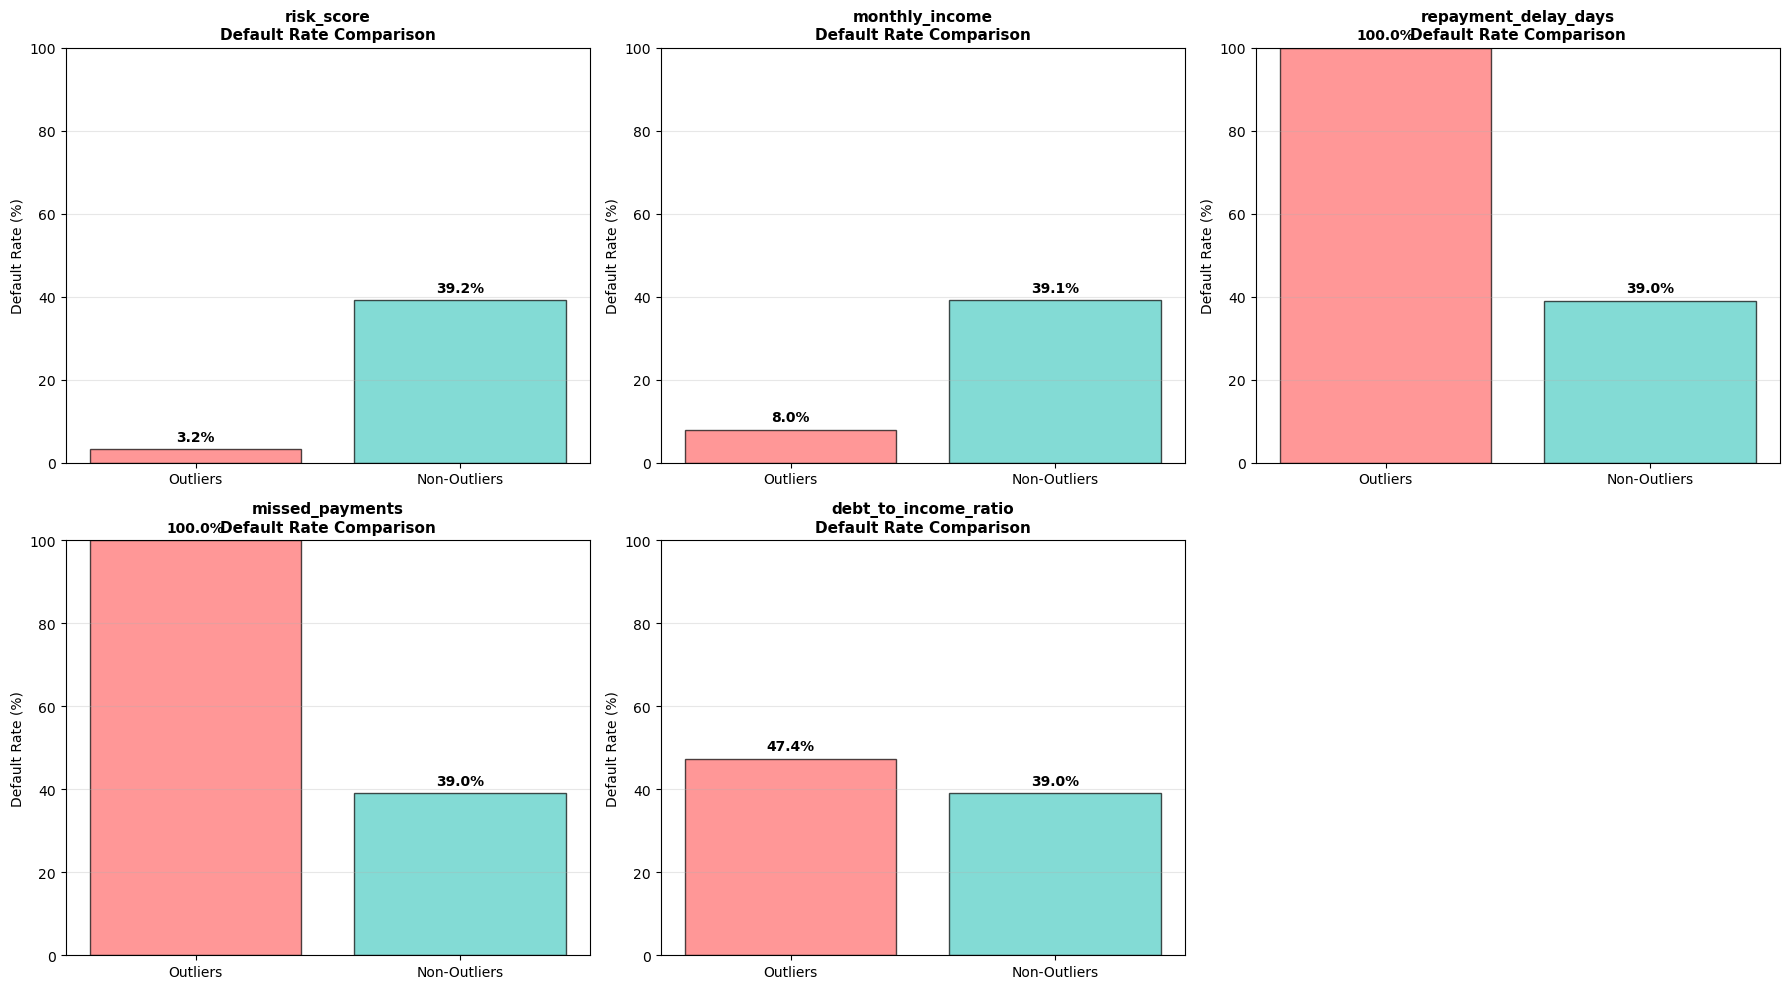

離群值 vs 非離群值的 Default 比例分析


,Variable,Outlier_Count,Normal_Count,Outlier_Default_Rate(%),Normal_Default_Rate(%),Difference(%)
0,risk_score,31,10314,3.23,39.16,-35.93
1,monthly_income,25,10320,8.00,39.13,-31.13
2,repayment_delay_days,1,10344,100.00,39.05,60.95
3,missed_payments,8,10337,100.00,39.01,60.99
4,debt_to_income_ratio,57,10288,47.37,39.01,8.36



詳細統計

📊 risk_score:
   離群值筆數: 31
   非離群值筆數: 10314
   離群值中 default 比例: 3.23%
   非離群值中 default 比例: 39.16%
   差異: -35.93%

📊 monthly_income:
   離群值筆數: 25
   非離群值筆數: 10320
   離群值中 default 比例: 8.00%
   非離群值中 default 比例: 39.13%
   差異: -31.13%

📊 repayment_delay_days:
   離群值筆數: 1
   非離群值筆數: 10344
   離群值中 default 比例: 100.00%
   非離群值中 default 比例: 39.05%
   差異: 60.95%

📊 missed_payments:
   離群值筆數: 8
   非離群值筆數: 10337
   離群值中 default 比例: 100.00%
   非離群值中 default 比例: 39.01%
   差異: 60.99%

📊 debt_to_income_ratio:
   離群值筆數: 57
   非離群值筆數: 10288
   離群值中 default 比例: 47.37%
   非離群值中 default 比例: 39.01%
   差異: 8.36%


In [2]:
# 分析五個具有離群值的變數：default_flag 在離群值 vs 非離群值的比例差異
outlier_vars = ['risk_score', 'monthly_income', 'repayment_delay_days', 'missed_payments', 'debt_to_income_ratio']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

comparison_results = []

for idx, col in enumerate(outlier_vars):
    # 計算 1.5 IQR 離群值界線
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 將資料分為離群值與非離群值
    is_outlier = (df[col] < lower_bound) | (df[col] > upper_bound)
    
    # 計算各組的 default 比例
    outlier_default_rate = df[is_outlier]['default_flag'].mean() * 100
    normal_default_rate = df[~is_outlier]['default_flag'].mean() * 100
    
    comparison_results.append({
        'Variable': col,
        'Outlier_Count': is_outlier.sum(),
        'Normal_Count': (~is_outlier).sum(),
        'Outlier_Default_Rate(%)': round(outlier_default_rate, 2),
        'Normal_Default_Rate(%)': round(normal_default_rate, 2),
        'Difference(%)': round(outlier_default_rate - normal_default_rate, 2)
    })
    
    # 繪製比較圖
    ax = axes[idx]
    categories = ['Outliers', 'Non-Outliers']
    rates = [outlier_default_rate, normal_default_rate]
    colors_bar = ['#ff6b6b', '#4ecdc4']
    
    bars = ax.bar(categories, rates, color=colors_bar, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}\nDefault Rate Comparison', fontsize=11, fontweight='bold')
    ax.set_ylabel('Default Rate (%)', fontsize=10)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    
    # 添加數值標籤
    for i, (bar, rate) in enumerate(zip(bars, rates)):
        ax.text(bar.get_x() + bar.get_width()/2, rate + 2, f'{rate:.1f}%', 
                ha='center', fontsize=10, fontweight='bold')

# 移除多餘的子圖
axes[5].remove()

plt.tight_layout()
plt.show()

# 顯示比較表格
print("=" * 100)
print("離群值 vs 非離群值的 Default 比例分析")
print("=" * 100)
comparison_df = pd.DataFrame(comparison_results)
display(comparison_df)

# 顯示詳細統計
print("\n" + "=" * 100)
print("詳細統計")
print("=" * 100)
for result in comparison_results:
    print(f"\n📊 {result['Variable']}:")
    print(f"   離群值筆數: {result['Outlier_Count']}")
    print(f"   非離群值筆數: {result['Normal_Count']}")
    print(f"   離群值中 default 比例: {result['Outlier_Default_Rate(%)']:.2f}%")
    print(f"   非離群值中 default 比例: {result['Normal_Default_Rate(%)']:.2f}%")
    print(f"   差異: {result['Difference(%)']:.2f}%")

## 抽樣偏誤之判斷

### 1. 目標變數比例 


在實際情況中，目標 target (是否違約)，違約比例不會這麼高(39.05%)，正常應該在個位數%。因此此資料集用來訓練真實世界分類模型會有所失真。

### 2. 就業狀態與月薪

| Type | Median($) |
| :--- | :--- |
| Salaried | 50,836.46 |
| Self-Employed | 60,824.92 |
| Student | 15,427.23 |
| Unemployed | 10,086.10 |

不管是下面四種圖示所式之分布或是 median 都可以明顯看出分佈符合 Self-Employed > Salaried > Student > Unemployed

但金錢上並沒有給單位，所以合理性可能會降低

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 設定圖表風格
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# 1. 箱線圖 - 不同 employment_type 下 monthly_income 的分布
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 箱線圖
ax1 = axes[0, 0]
sns.boxplot(data=df, x='employment_type', y='monthly_income', ax=ax1, palette='Set2')
ax1.set_title('Monthly Income Distribution by Employment Type (Box Plot)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Employment Type', fontsize=10)
ax1.set_ylabel('Monthly Income', fontsize=10)
ax1.tick_params(axis='x', rotation=45)

# 小提琴圖
ax2 = axes[0, 1]
sns.violinplot(data=df, x='employment_type', y='monthly_income', ax=ax2, palette='Set2')
ax2.set_title('Monthly Income Distribution by Employment Type (Violin Plot)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Employment Type', fontsize=10)
ax2.set_ylabel('Monthly Income', fontsize=10)
ax2.tick_params(axis='x', rotation=45)

# 條紋圖 + 箱線圖
ax3 = axes[1, 0]
sns.stripplot(data=df, x='employment_type', y='monthly_income', ax=ax3, alpha=0.4, size=3, jitter=True, palette='Set2')
sns.boxplot(data=df, x='employment_type', y='monthly_income', ax=ax3, width=0.5, palette='Set2', showcaps=False, boxprops=dict(alpha=0.7), whiskerprops=dict(alpha=0.7), medianprops=dict(color='red', linewidth=2))
ax3.set_title('Monthly Income Distribution by Employment Type (Strip + Box Plot)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Employment Type', fontsize=10)
ax3.set_ylabel('Monthly Income', fontsize=10)
ax3.tick_params(axis='x', rotation=45)

# 直方圖
ax4 = axes[1, 1]
employment_types = df['employment_type'].unique()
colors = sns.color_palette('Set2', len(employment_types))
for i, emp_type in enumerate(employment_types):
    data = df[df['employment_type'] == emp_type]['monthly_income']
    ax4.hist(data, alpha=0.6, label=emp_type, bins=30, color=colors[i])
ax4.set_title('Monthly Income Distribution by Employment Type (Histogram)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Monthly Income', fontsize=10)
ax4.set_ylabel('Frequency', fontsize=10)
ax4.legend()

plt.tight_layout()
plt.show()

# 統計摘要
print("=" * 80)
print("Monthly Income Distribution by Employment Type - Statistics")
print("=" * 80)

for emp_type in sorted(df['employment_type'].unique()):
    data = df[df['employment_type'] == emp_type]['monthly_income']
    print(f"\n📊 {emp_type}:")
    print(f"   Count: {len(data)}")
    print(f"   Mean: ${data.mean():,.2f}")
    print(f"   Median: ${data.median():,.2f}")
    print(f"   Std Dev: ${data.std():,.2f}")
    print(f"   Min: ${data.min():,.2f}")
    print(f"   Max: ${data.max():,.2f}")
    print(f"   25th Percentile: ${data.quantile(0.25):,.2f}")
    print(f"   75th Percentile: ${data.quantile(0.75):,.2f}")
    print(f"   IQR: ${data.quantile(0.75) - data.quantile(0.25):,.2f}")

# 統計表格
print("\n" + "=" * 80)
print("Summary Statistics Table")
print("=" * 80)
summary_stats = df.groupby('employment_type')['monthly_income'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('25%', lambda x: x.quantile(0.25)),
    ('75%', lambda x: x.quantile(0.75))
]).round(2)
display(summary_stats)

### 3. 國家類別與月薪

月薪並未依照國家而有所不同，這與常識認知完全不相同。
僅看四種分佈圖就可看出月薪並未按照國家種類而有區別

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 設定圖表風格
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# location 與 monthly_income 的分布分析
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 箱線圖
ax1 = axes[0, 0]
sns.boxplot(data=df, x='location', y='monthly_income', ax=ax1, palette='Set3')
ax1.set_title('Monthly Income Distribution by Location (Box Plot)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Location', fontsize=10)
ax1.set_ylabel('Monthly Income', fontsize=10)
ax1.tick_params(axis='x', rotation=45)

# 小提琴圖
ax2 = axes[0, 1]
sns.violinplot(data=df, x='location', y='monthly_income', ax=ax2, palette='Set3')
ax2.set_title('Monthly Income Distribution by Location (Violin Plot)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Location', fontsize=10)
ax2.set_ylabel('Monthly Income', fontsize=10)
ax2.tick_params(axis='x', rotation=45)

# 條紋圖 + 箱線圖
ax3 = axes[1, 0]
sns.stripplot(data=df, x='location', y='monthly_income', ax=ax3, alpha=0.4, size=3, jitter=True, palette='Set3')
sns.boxplot(data=df, x='location', y='monthly_income', ax=ax3, width=0.5, palette='Set3', showcaps=False, boxprops=dict(alpha=0.7), whiskerprops=dict(alpha=0.7), medianprops=dict(color='red', linewidth=2))
ax3.set_title('Monthly Income Distribution by Location (Strip + Box Plot)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Location', fontsize=10)
ax3.set_ylabel('Monthly Income', fontsize=10)
ax3.tick_params(axis='x', rotation=45)

# 直方圖
ax4 = axes[1, 1]
locations = sorted(df['location'].unique())
colors = sns.color_palette('Set3', len(locations))
for i, location in enumerate(locations):
    data = df[df['location'] == location]['monthly_income']
    ax4.hist(data, alpha=0.6, label=location, bins=30, color=colors[i])
ax4.set_title('Monthly Income Distribution by Location (Histogram)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Monthly Income', fontsize=10)
ax4.set_ylabel('Frequency', fontsize=10)
ax4.legend()

plt.tight_layout()
plt.show()

# 統計摘要
print("=" * 80)
print("Monthly Income Distribution by Location - Statistics")
print("=" * 80)

for location in sorted(df['location'].unique()):
    data = df[df['location'] == location]['monthly_income']
    print(f"\n📍 {location}:")
    print(f"   Count: {len(data)}")
    print(f"   Mean: ${data.mean():,.2f}")
    print(f"   Median: ${data.median():,.2f}")
    print(f"   Std Dev: ${data.std():,.2f}")
    print(f"   Min: ${data.min():,.2f}")
    print(f"   Max: ${data.max():,.2f}")
    print(f"   25th Percentile: ${data.quantile(0.25):,.2f}")
    print(f"   75th Percentile: ${data.quantile(0.75):,.2f}")
    print(f"   IQR: ${data.quantile(0.75) - data.quantile(0.25):,.2f}")

# 統計表格
print("\n" + "=" * 80)
print("Summary Statistics Table")
print("=" * 80)
summary_stats_location = df.groupby('location')['monthly_income'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('25%', lambda x: x.quantile(0.25)),
    ('75%', lambda x: x.quantile(0.75))
]).round(2)
display(summary_stats_location)

### 4. 信用分數 (Credit Score) 的跨國矛盾？

資料使用了 300-850 這個典型的「美國 FICO 分數」區間。但是！印度的信用評分標準（CIBIL）或英國的標準，跟美國是完全不同的。
但 location 對 credit_score 的影響幾乎不存在，代表生成器粗暴地把美國標準套用在全世界，這在跨國預測上是嚴重的偏誤。

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 設定圖表風格
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# credit_score 與 location 的分布分析
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 箱線圖
ax1 = axes[0, 0]
sns.boxplot(data=df, x='location', y='credit_score', ax=ax1, palette='Set2')
ax1.set_title('Credit Score Distribution by Location (Box Plot)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Location', fontsize=10)
ax1.set_ylabel('Credit Score', fontsize=10)
ax1.tick_params(axis='x', rotation=45)

# 小提琴圖
ax2 = axes[0, 1]
sns.violinplot(data=df, x='location', y='credit_score', ax=ax2, palette='Set2')
ax2.set_title('Credit Score Distribution by Location (Violin Plot)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Location', fontsize=10)
ax2.set_ylabel('Credit Score', fontsize=10)
ax2.tick_params(axis='x', rotation=45)

# 條紋圖 + 箱線圖
ax3 = axes[1, 0]
sns.stripplot(data=df, x='location', y='credit_score', ax=ax3, alpha=0.4, size=3, jitter=True, palette='Set2')
sns.boxplot(data=df, x='location', y='credit_score', ax=ax3, width=0.5, palette='Set2', showcaps=False, boxprops=dict(alpha=0.7), whiskerprops=dict(alpha=0.7), medianprops=dict(color='red', linewidth=2))
ax3.set_title('Credit Score Distribution by Location (Strip + Box Plot)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Location', fontsize=10)
ax3.set_ylabel('Credit Score', fontsize=10)
ax3.tick_params(axis='x', rotation=45)

# 直方圖
ax4 = axes[1, 1]
locations = sorted(df['location'].unique())
colors = sns.color_palette('Set2', len(locations))
for i, location in enumerate(locations):
    data = df[df['location'] == location]['credit_score']
    ax4.hist(data, alpha=0.6, label=location, bins=30, color=colors[i])
ax4.set_title('Credit Score Distribution by Location (Histogram)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Credit Score', fontsize=10)
ax4.set_ylabel('Frequency', fontsize=10)
ax4.legend()

plt.tight_layout()
plt.show()

# 統計摘要
print("=" * 80)
print("Credit Score Distribution by Location - Statistics")
print("=" * 80)

for location in sorted(df['location'].unique()):
    data = df[df['location'] == location]['credit_score']
    print(f"\n📍 {location}:")
    print(f"   Count: {len(data)}")
    print(f"   Mean: {data.mean():.2f}")
    print(f"   Median: {data.median():.2f}")
    print(f"   Std Dev: {data.std():.2f}")
    print(f"   Min: {data.min():.0f}")
    print(f"   Max: {data.max():.0f}")
    print(f"   25th Percentile: {data.quantile(0.25):.2f}")
    print(f"   75th Percentile: {data.quantile(0.75):.2f}")
    print(f"   IQR: {data.quantile(0.75) - data.quantile(0.25):.2f}")

# 統計表格
print("\n" + "=" * 80)
print("Summary Statistics Table")
print("=" * 80)
summary_stats_credit = df.groupby('location')['credit_score'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Median', 'median'),
    ('Std Dev', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('25%', lambda x: x.quantile(0.25)),
    ('75%', lambda x: x.quantile(0.75))
]).round(2)
display(summary_stats_credit)

### 5. 遲繳天數與違約的關係


檢查 repayment_delay_days (遲繳天數)、missed_payments (漏繳次數) 與 default_flag (違約) 的關係。

確實遲繳與漏繳情況在違約(default_flag = 1)值較大

但理論上有遲繳、漏繳應該就算違約

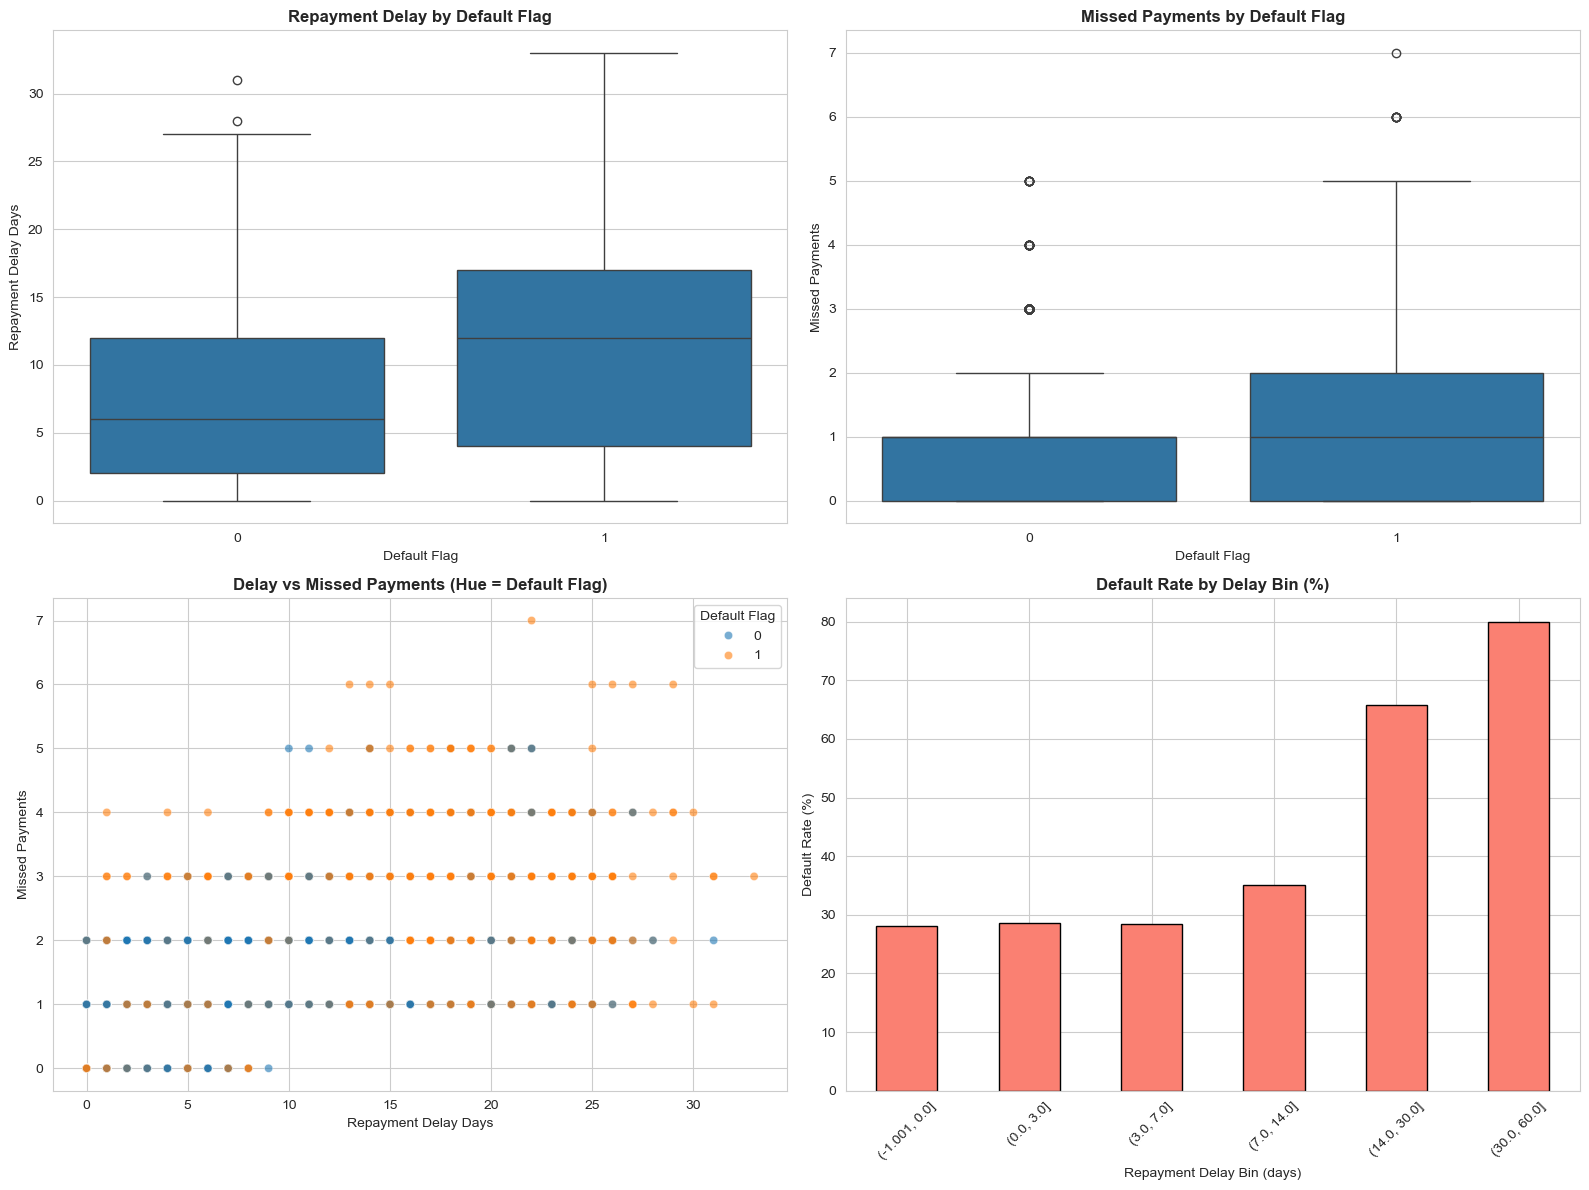

Delay/Missed Payments vs Default - Summary
Default rate by missed payments:


missed_payments
0     27.73
1     37.58
2     44.54
3     82.39
4     87.41
5     74.19
6    100.00
7    100.00
Name: default_flag, dtype: float64

Default rate by delay bin (%):


delay_bin
(-1.001, 0.0]    28.06
(0.0, 3.0]       28.57
(3.0, 7.0]       28.41
(7.0, 14.0]      35.02
(14.0, 30.0]     65.76
(30.0, 60.0]     80.00
Name: default_flag, dtype: float64

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")

analysis_df = df[['repayment_delay_days', 'missed_payments', 'default_flag']].dropna().copy()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=analysis_df, x='default_flag', y='repayment_delay_days', ax=axes[0, 0])
axes[0, 0].set_title('Repayment Delay by Default Flag', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Default Flag', fontsize=10)
axes[0, 0].set_ylabel('Repayment Delay Days', fontsize=10)

sns.boxplot(data=analysis_df, x='default_flag', y='missed_payments', ax=axes[0, 1])
axes[0, 1].set_title('Missed Payments by Default Flag', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Default Flag', fontsize=10)
axes[0, 1].set_ylabel('Missed Payments', fontsize=10)

sns.scatterplot(data=analysis_df, x='repayment_delay_days', y='missed_payments', hue='default_flag', ax=axes[1, 0], alpha=0.6)
axes[1, 0].set_title('Delay vs Missed Payments (Hue = Default Flag)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Repayment Delay Days', fontsize=10)
axes[1, 0].set_ylabel('Missed Payments', fontsize=10)
axes[1, 0].legend(title='Default Flag')

delay_max = analysis_df['repayment_delay_days'].max()
upper = max(delay_max, 90) + 1
delay_bins = [-1, 0, 3, 7, 14, 30, 60, 90, upper]
analysis_df['delay_bin'] = pd.cut(analysis_df['repayment_delay_days'], bins=delay_bins, include_lowest=True)
default_rate = analysis_df.groupby('delay_bin')['default_flag'].mean().mul(100)
default_rate.plot(kind='bar', ax=axes[1, 1], color='salmon', edgecolor='black')
axes[1, 1].set_title('Default Rate by Delay Bin (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Repayment Delay Bin (days)', fontsize=10)
axes[1, 1].set_ylabel('Default Rate (%)', fontsize=10)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("=" * 80)
print("Delay/Missed Payments vs Default - Summary")
print("=" * 80)
print("Default rate by missed payments:")
display(analysis_df.groupby('missed_payments')['default_flag'].mean().mul(100).round(2))

print("Default rate by delay bin (%):")
display(default_rate.round(2))


### 6. customer_segment 比例
在 default_flag 不同下，確實其比例在違約時，high_risk 較多，但同時 high_risk 在實務上比例不可能這麼大。

Customer Segment Overall (%)
customer_segment
High Risk      73.17
Medium Risk    21.27
Low Risk        5.57
Name: proportion, dtype: float64


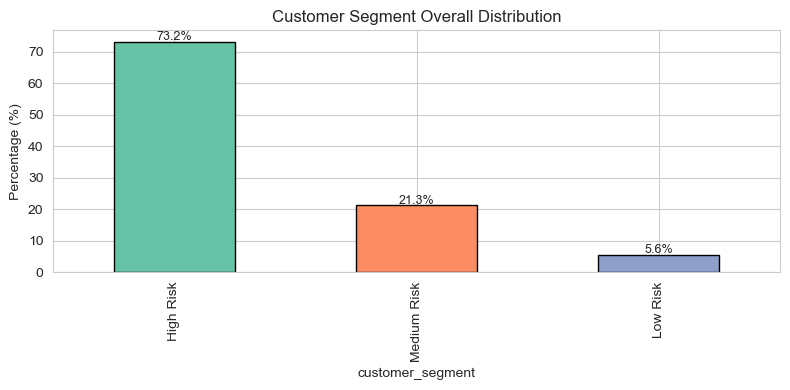


Customer Segment Percentage by default_flag (%)


customer_segment,High Risk,Low Risk,Medium Risk
default_flag,,,
0,60.56,8.58,30.86
1,92.85,0.87,6.29


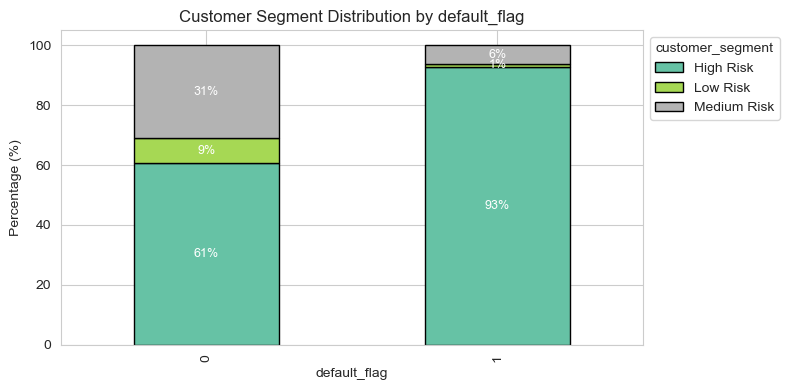

In [5]:
# 顯示 customer_segment 整體比例與在 default_flag 下的比例（%）
overall = df['customer_segment'].value_counts(normalize=True).mul(100).round(2)
print("Customer Segment Overall (%)")
print(overall)

# 繪圖 - 整體比例
ax = overall.plot(kind='bar', color=sns.color_palette('Set2', len(overall)), edgecolor='black', figsize=(8,4))
ax.set_ylabel('Percentage (%)')
ax.set_title('Customer Segment Overall Distribution')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x()+p.get_width()/2, p.get_height()+0.5), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# 按 default_flag 的比例
by_flag = df.groupby('default_flag')['customer_segment'].value_counts(normalize=True).unstack(fill_value=0).mul(100).round(2)
print("\nCustomer Segment Percentage by default_flag (%)")
display(by_flag)

# 繪圖 - default_flag 下的分布（堆疊長條圖）
ax = by_flag.plot(kind='bar', stacked=True, figsize=(8,4), colormap='Set2', edgecolor='black')
ax.set_ylabel('Percentage (%)')
ax.set_title('Customer Segment Distribution by default_flag')
ax.legend(title='customer_segment', bbox_to_anchor=(1,1))
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x()+p.get_width()/2, p.get_y()+h/2, f"{h:.0f}%", ha='center', va='center', color='white', fontsize=9)
plt.tight_layout()
plt.show()

## 編碼一致性

同一個意思，在資料庫裡卻有各種不同的寫法。這在類別型特徵 (Categorical features) 中極常見。
例如「性別」欄位同時出現了 Male, M, 男, 1。對人類來說這都是同一個意思，但對分類演算法來說，這是「4種完全不同的特徵」。

又或是變數陳述的範圍跟實際範圍不一樣。
例如：credit_score 陳述範圍在 300~850，但實際卻存在超過 850 的資料。

## 有無冗餘變數
risk_score, credit_score, customer_segment 在意義上太過於接近 default_flag 先暫時假定其為冗餘變數。
而 user_id 與預測無關，定其為冗餘變數。